<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; ">Détection de faux billets en euros - Python </h1>
</div>

## Objectif

En tant qu'un consultant sénior Data Analyst. On travaille pour l’Organisation nationale de lutte contre le faux-monnayage (ONCFM) qui cherche à mettre en place des méthodes d’**identification des contrefaçons des billets en euros**. 

Pour se faire, nous allons utiliser les données géométriques collectées par la machine de comptage des billets. Ensuite, nous allons tester 4 méthodes de classification. Une méthode non-supervisée et 3 méthodes supervisée.

**Plan :** 
- Analyse exploratoire des caractéristiques
- Nettoyage des données
- Optimiser les modèles entrainés
- Comparer la performance entre ces modèles


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des données </h2>
</div>

### Importation des packages

In [131]:
import os
import numpy as np
import scipy.stats as stats
import pandas as pd
import openpyxl
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA


import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from mlxtend.feature_selection import SequentialFeatureSelector

from sklearn import metrics
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.metrics import roc_curve
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import silhouette_score

### Importation de données

In [132]:
DATA_PATH = "billets.csv"

if not os.path.exists(DATA_PATH):
    print(f"Attention : le fichier '{DATA_PATH}' n'existe pas.")

try:
    billet = pd.read_csv(DATA_PATH, sep=";")
    print("Données chargées :", billet.shape)
    display(billet.head())
    display(billet.info())
except Exception as e:
    print("Erreur lors du chargement :", e)
    print("Tu as bien lu le code avant de l'executer ? ")


Données chargées : (1500, 7)


,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_genuine    1500 non-null   bool   
 1   diagonal      1500 non-null   float64
 2   height_left   1500 non-null   float64
 3   height_right  1500 non-null   float64
 4   margin_low    1463 non-null   float64
 5   margin_up     1500 non-null   float64
 6   length        1500 non-null   float64
dtypes: bool(1), float64(6)
memory usage: 71.9 KB


None

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse descriptive et transformation des données </h2>
</div>

<div style="background-color: RGB(51,100,182);" >
<h2 style="margin: auto; padding: 16px; color:#fff; "> I - Analyse exploratoire (EDA) </h2>
</div>

In [133]:
# Résumé des données numériques
summary_data = billet.describe().round(2)
summary_data.to_excel("data_description.xlsx", sheet_name = "tab_desciption")
print(summary_data)

       diagonal  height_left  height_right  margin_low  margin_up   length
count   1500.00      1500.00       1500.00     1463.00    1500.00  1500.00
mean     171.96       104.03        103.92        4.49       3.15   112.68
std        0.31         0.30          0.33        0.66       0.23     0.87
min      171.04       103.14        102.82        2.98       2.27   109.49
25%      171.75       103.82        103.71        4.01       2.99   112.03
50%      171.96       104.04        103.92        4.31       3.14   112.96
75%      172.17       104.23        104.15        4.87       3.31   113.34
max      173.01       104.88        104.95        6.90       3.91   114.44


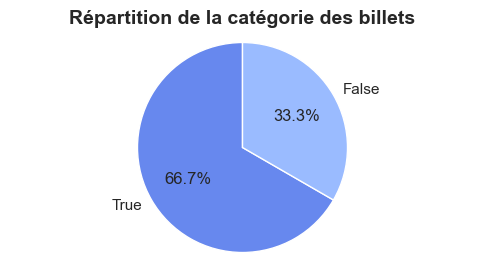

In [134]:
# Répartition des catégories des billets
counts = billet["is_genuine"].value_counts()

# Camembert
plt.figure()
plt.pie(counts.values, labels=counts.index, autopct='%1.1f%%', startangle=90)
sns.set_palette("coolwarm")  #muted, bright, deep, pastel, "coolwarm"
plt.title("Répartition de la catégorie des billets", fontsize = "14", fontweight = 'bold')
plt.axis('equal')  # pour un cercle parfait

plt.savefig("camembert_billet.png")
plt.show()

On peut voir que la classe "is_genuine" est bien déséquilibrée. Les faux billets ne présentent que *$1/3$* et les vrais billets *$2/3$*.

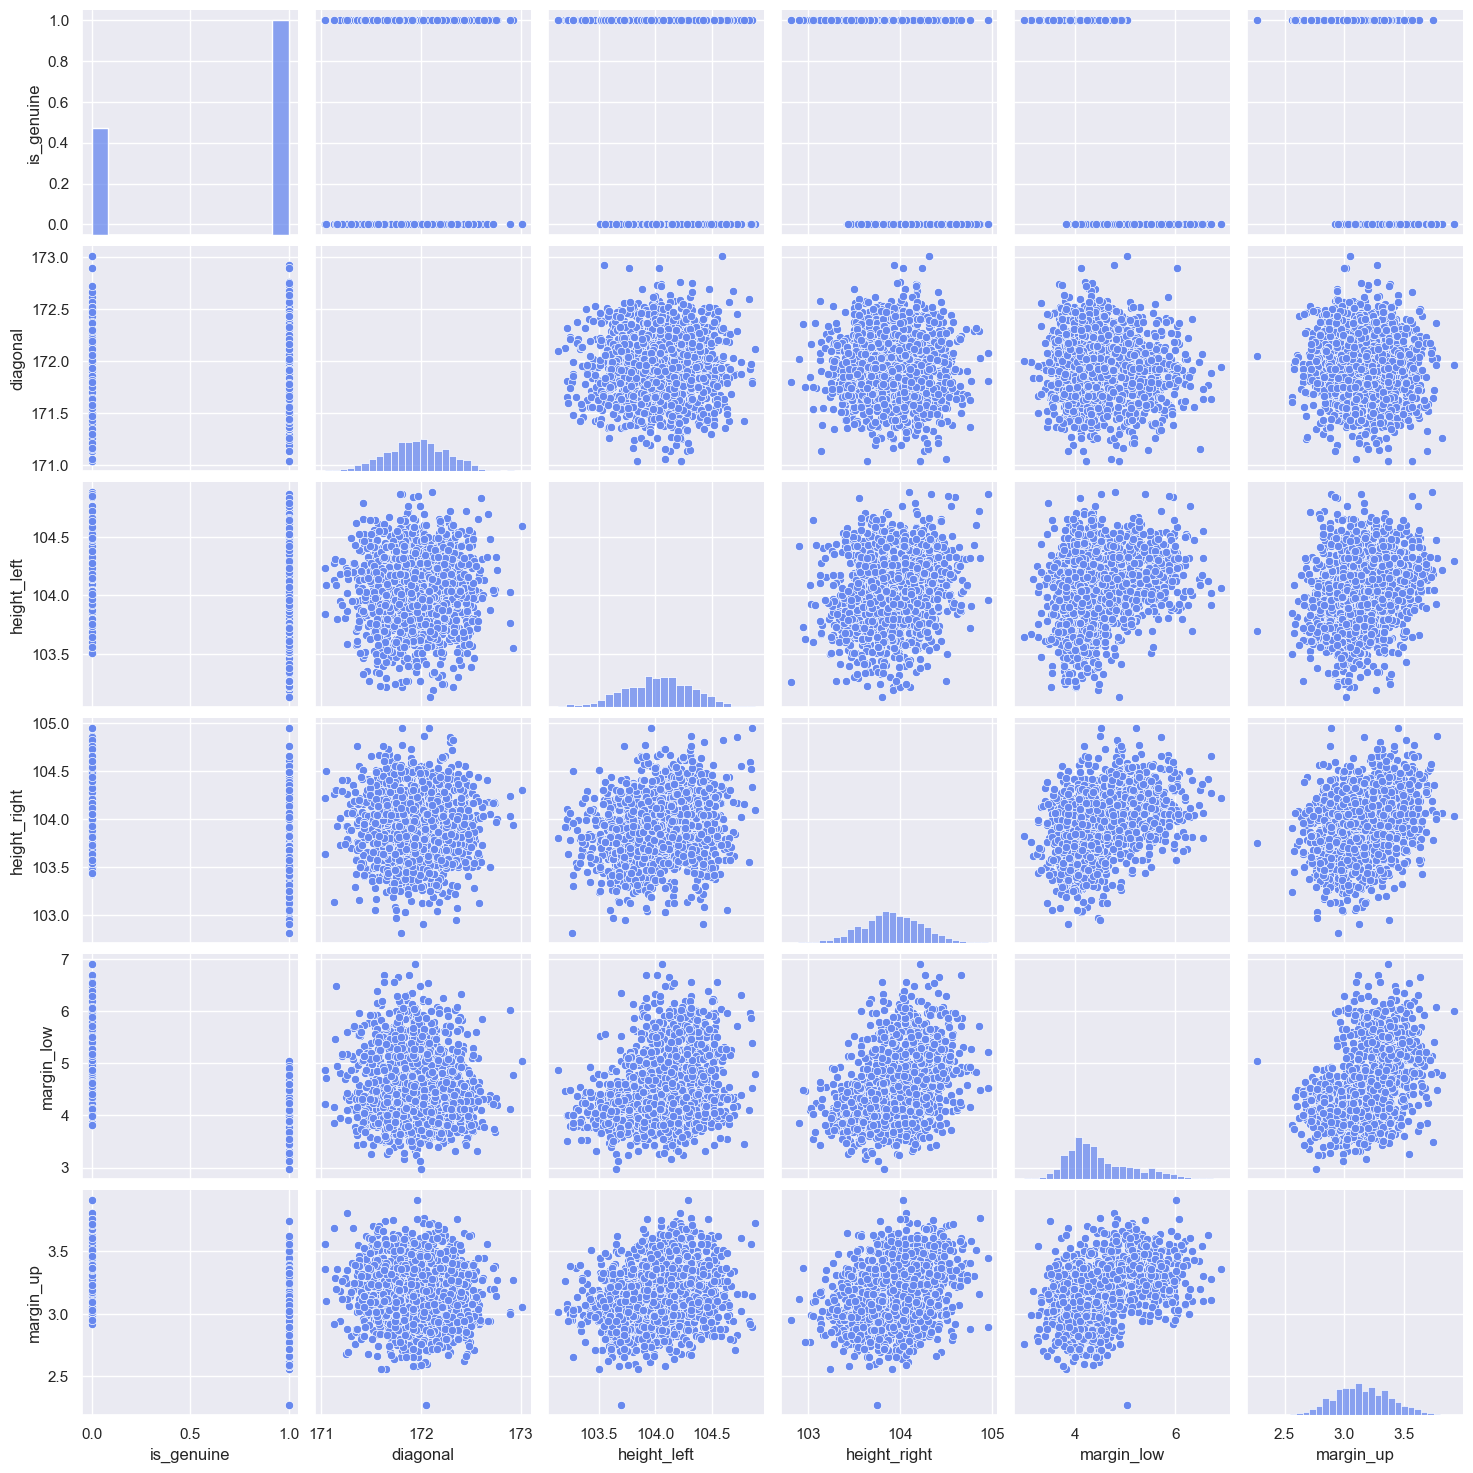

In [135]:
# Relation 2 à 2 entre les variables
sns.pairplot(billet.iloc[:,0:6])
plt.savefig("relation2à2.png")
plt.show()

C:\Users\cairo\AppData\Local\Temp\ipykernel_13732\2715219696.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


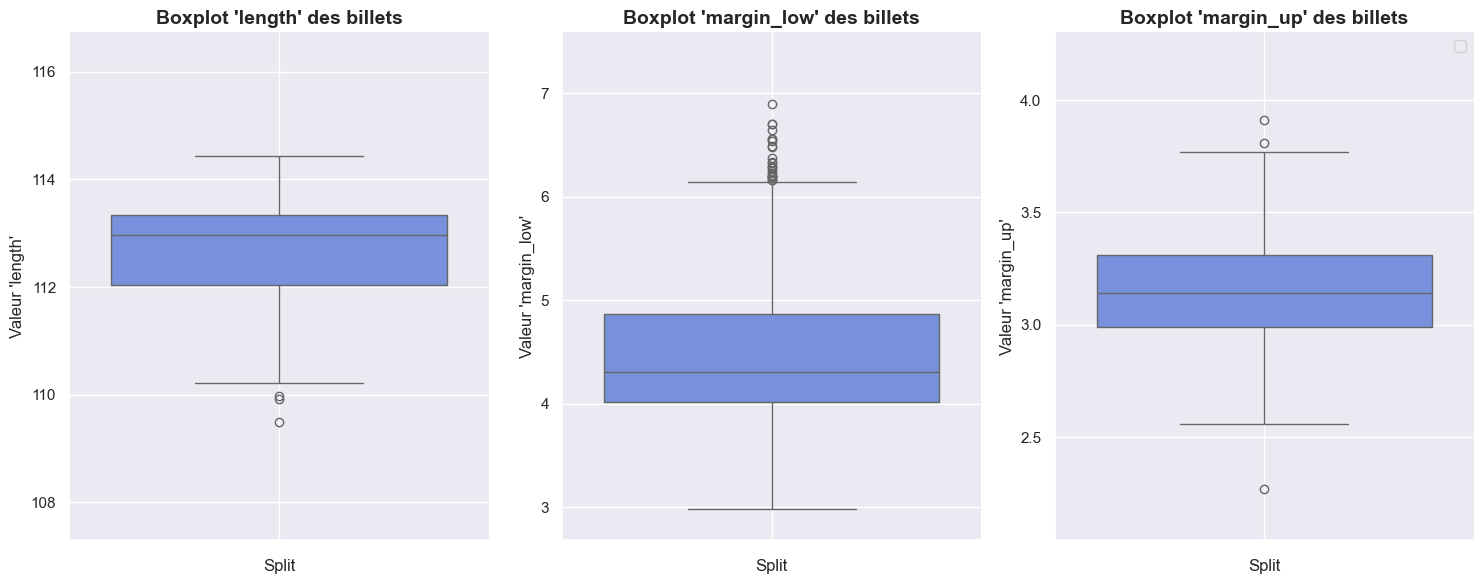

In [136]:
fig = plt.figure(figsize=(15,6))
ax = fig.add_subplot(1, 3, 1)
sns.boxplot(y="length", data=billet)

ax.grid(True, which = 'both')
ax.set_title('Boxplot \'length\' des billets', fontweight = 'bold', fontsize = 14)
ax.set_xlabel('Split')
ax.set_ylabel('Valeur \'length\'')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0.98 * np.min(billet["length"]), 1.02 * np.max(billet["length"]))


ax = fig.add_subplot(1, 3, 2)
sns.boxplot(y="margin_low", data=billet)

ax.grid(True, which = 'both')
ax.set_title('Boxplot \'margin_low\' des billets', fontweight = 'bold', fontsize = 14)
ax.set_xlabel('Split')
ax.set_ylabel('Valeur \'margin_low\'')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0.9 * np.min(billet["margin_low"]), 1.1 * np.max(billet["margin_low"]))


ax = fig.add_subplot(1, 3, 3)
sns.boxplot(y="margin_up", data=billet)

ax.grid(True, which = 'both')
ax.set_title('Boxplot \'margin_up\' des billets', fontweight = 'bold', fontsize = 14)
ax.set_xlabel('Split')
ax.set_ylabel('Valeur \'margin_up\'')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0.9 * np.min(billet["margin_up"]), 1.1 * np.max(billet["margin_up"]))


ax.legend()
plt.tight_layout()

plt.savefig("Boxplt_len_margin_up_low.png")
plt.show()

D'après le graphique, on voit bien que la variable "is_genuine" sont bien classifiés d'après la variable "margin_low".

              is_genuine  diagonal  height_left  height_right  margin_low  \
is_genuine      1.000000  0.132756    -0.379833     -0.485092   -0.783032   
diagonal        0.132756  1.000000     0.019472     -0.024492   -0.111534   
height_left    -0.379833  0.019472     1.000000      0.242279    0.302643   
height_right   -0.485092 -0.024492     0.242279      1.000000    0.391085   
margin_low     -0.783032 -0.111534     0.302643      0.391085    1.000000   
margin_up      -0.606262 -0.055649     0.246522      0.307005    0.431606   
length          0.849285  0.097587    -0.320863     -0.401751   -0.666753   

              margin_up    length  
is_genuine    -0.606262  0.849285  
diagonal      -0.055649  0.097587  
height_left    0.246522 -0.320863  
height_right   0.307005 -0.401751  
margin_low     0.431606 -0.666753  
margin_up      1.000000 -0.520575  
length        -0.520575  1.000000  


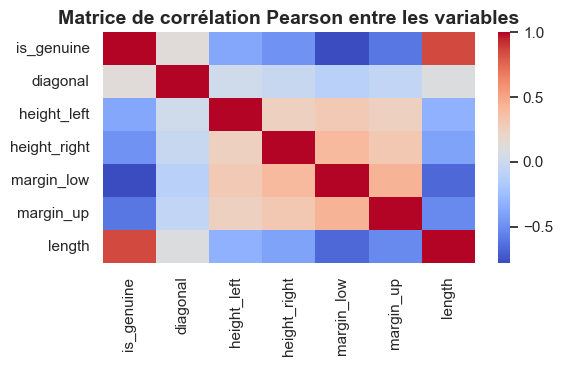

In [137]:
## Matrice de corrélation
billet_corr = billet.corr()
print(billet_corr)
sns.set(rc={'figure.figsize':(6,3)})
sns.heatmap(billet_corr, xticklabels = billet_corr.columns , 
                 yticklabels = billet_corr.columns, cmap = 'coolwarm')

plt.title("Matrice de corrélation Pearson entre les variables", fontsize = 14, fontweight = 'bold')
plt.savefig("matrix_corr.png")
plt.show()

On remarque bien que les variables telles que "margin_low" et "length" sont bien corrélées linéairement avec notre variable cible (de manière négatif ou positif). Ainsi, il est très important de s'assurer que leurs valeurs sont bien représentés. 

Il est donc important de prédire les valeurs de margin_low qui sont vides.

<div style="background-color: RGB(51,100,182);" >
<h2 style="margin: auto; padding: 16px; color:#fff; ">II - Prétraitement des données </h2>
</div>

<div style="background-color: RGB(51,130,182);" >
<h3 style="margin: auto; padding: 20px; color:#fff; ">"Margin_low" à prédire </h3>
</div>

In [138]:
# Encoder les valeurs catégorielles ou booléennes ici en numérique
billet["is_genuine"] = (
    billet["is_genuine"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({"false": 1, "true": 0})
)

print(billet.dtypes)

is_genuine        int64
diagonal        float64
height_left     float64
height_right    float64
margin_low      float64
margin_up       float64
length          float64
dtype: object


### 1. Séparation des données en 80% train/ 20% test

In [139]:
# Extraire les données disponibles non vide
X_marginlow = billet.loc[~billet["margin_low"].isna(), ["diagonal", "height_left", "height_right", "margin_up", "length", "is_genuine"]]
y_marginlow = billet.loc[~billet["margin_low"].isna(), "margin_low"]

# Diviser en 2 jeux de données train et test (20% test)
X_train_ml, X_test_ml, y_train_ml, y_test_ml = train_test_split(X_marginlow, y_marginlow, test_size=0.20, random_state=42)

In [140]:
# Modèle linéaire
X_const = sm.add_constant(X_train_ml)
reg_ml = sm.OLS(y_train_ml, X_train_ml).fit()
print(reg_ml.summary())

                                 OLS Regression Results                                
Dep. Variable:             margin_low   R-squared (uncentered):                   0.991
Model:                            OLS   Adj. R-squared (uncentered):              0.991
Method:                 Least Squares   F-statistic:                          2.238e+04
Date:                Tue, 14 Apr 2026   Prob (F-statistic):                        0.00
Time:                        19:06:46   Log-Likelihood:                         -646.10
No. Observations:                1170   AIC:                                      1304.
Df Residuals:                    1164   BIC:                                      1335.
Df Model:                           6                                                  
Covariance Type:            nonrobust                                                  
                   coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------

On peut voir depuis ce modèle que la régression linéaire est globalement significative avec Prob(F-statistic) < 5%. Par ailleurs, il n'est pas le cas pour chaque variable de cette regression linéaire.

### 2. Validation des hypothèses

Espérance des résidus
count    1170.000000
mean        0.000003
std         0.420510
min        -1.372094
25%        -0.279199
50%        -0.007074
75%         0.254983
max         1.692656
dtype: float64
Normalité des résidus


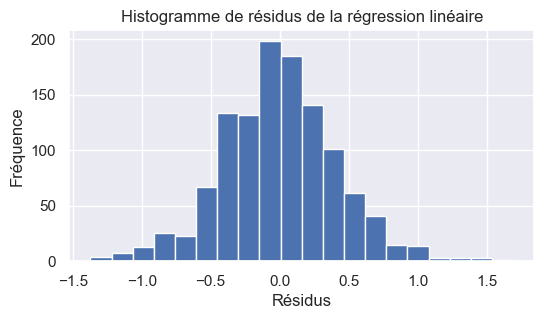

QQ plot


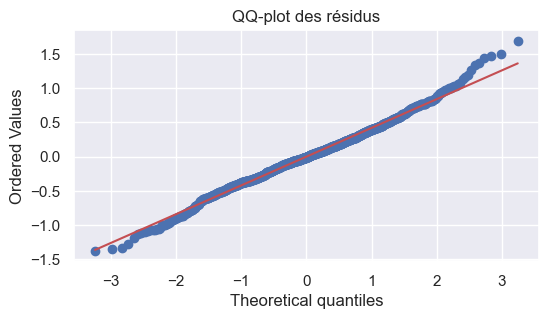

Test de Shapiro
p-value = 0.0000
Test de KS
p-value = 0.2764
Homocédasticité des résidus


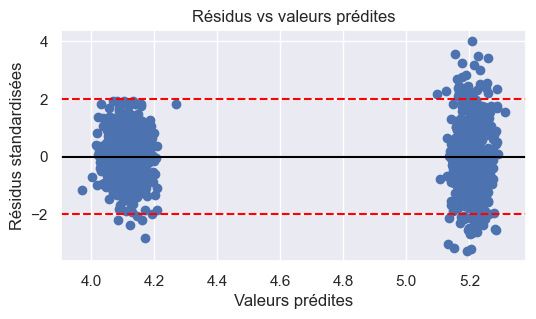

Test de breusch-pagan
{'LM Statistic': np.float64(148.2795810900006), 'LM-Test p-value': np.float64(1.7876601352423532e-29), 'F-Statistic': np.float64(28.13051881512498), 'F-Test p-value': np.float64(1.6706790844416819e-31)}
Colinéarité des variables
       Variable            VIF
0      diagonal  169126.150889
1   height_left  117811.318777
2  height_right  110579.305355
3     margin_up     298.822160
4        length   51901.395476
5    is_genuine       6.918207


In [141]:
# Validation des hypothèses 
y_pred_train_ml = reg_ml.predict(X_train_ml)
res_train_ml = y_train_ml - y_pred_train_ml

## distribution normale 
print("Espérance des résidus")
print(res_train_ml.describe())

print("Normalité des résidus")
plt.hist(res_train_ml, bins=20)
plt.xlabel("Résidus")
plt.ylabel("Fréquence")
plt.title("Histogramme de résidus de la régression linéaire")
plt.show()

## QQ-plot
print("QQ plot")
stats.probplot(res_train_ml, plot=plt, dist = "norm") # verifier si proche de loi normale
plt.title("QQ-plot des résidus")
plt.show()
# Existe des valeurs aberrantes

## Test Shapiro
print("Test de Shapiro")
stat, p_value = stats.shapiro(res_train_ml)
print(f"p-value = {p_value:.4f}")
# rejette la normalité (p-value < 5%)


## Test Kolmogorov–Smirnov (avec standardisation)
print("Test de KS")
stat, p_value = stats.kstest(
    (res_train_ml - res_train_ml.mean()) / res_train_ml.std(ddof=1),
    'norm')
print(f"p-value = {p_value:.4f}")
# rejette également si p_value < 5% 
# Ici, on accepte


# Homocédasticité des résidus ?
print("Homocédasticité des résidus")
# Écart-type des résidus
sigma = np.std(res_train_ml, ddof=1)
# Résidus standardisés 
plt.scatter(y_pred_train_ml, res_train_ml/sigma)
plt.axhline(0, color = "black")
plt.axhline(-2, color = "red", linestyle='--')
plt.axhline(2, color = "red", linestyle='--')
plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus standardisées")
plt.title("Résidus vs valeurs prédites")
plt.show()
# certains résidus ne sont pas acceptables

# Homoscédasticité : breusch-pagan
print("Test de breusch-pagan")
bp_test = het_breuschpagan(reg_ml.resid, sm.add_constant(X_train_ml))
labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
print(dict(zip(labels, bp_test)))

# Colinéarité  des variables ?
print("Colinéarité des variables")
X = X_train_ml
vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i)
              for i in range(X.shape[1])]

print(vif)
# On observe une régression linéaire très forte entre les variables explicatives
# => il faut donc enlever les variables qui sont fortement corrélées entre elles et faibelment corrélées avec is_genuine, telles que diagonal, height_left, height_right

Les hypothèses des résidus sont vérifiées pour cette régression linéaire pourtant on a des variables explicatives qui sont fortement corrélées linéairement entre elles d'après le résultat de VIF. On cherche ainsi à employer la méthode de **forward** et le **critère de $R^2_{ajusted}$** afin de sélectionner les variables réellement significatives.

De plus, pour éviter le déséquilibre de classe des billets 'vrai' et 'faux' dans l'échantillon d'entrainement et de l'échantillon de test. L'ensemble des données sera diviser en **k = 5** sous-échantillons de manière aléatoire. 

La régression sera entrainer sur les sous-échantillons train et tester sur les échantillons test. Ce processus répété en **k=5** fois donnera une moyenne de performance ($R^2_{ajusted}$) des échantillons test. 

On prendra le modèle linéaire qui est le plus performant.

<div style="background-color: RGB(51,130,182);" >
<h3 style="margin: auto; padding: 20px; color:#fff; ">Optimisation de la régression linéaire </h3>
</div>

### 1. Modèle linéaire avec la validation croisée

In [142]:
# Etablir le score R2 ajustée
def r2_score_adj(estimator, X, y):
    """ Fonction de calcul de r2 score adjusted """
    y_pred = estimator.predict(X)

    if estimator.fit_intercept:
        rsquared = 1 - np.nansum((y - y_pred) ** 2) / np.nansum((y - np.nanmean(y)) ** 2)
        rsquared_adj = 1 - (X.shape[0] - 1) / (X.shape[0] - X.shape[1] - 1) * (1 - rsquared)

    else:
        rsquared = 1 - np.nansum((y - y_pred) ** 2) / np.nansum(y ** 2)
        rsquared_adj = 1 - X.shape[0] / (X.shape[0] - X.shape[1]) * (1 - rsquared)

    return rsquared_adj


# Définir la validation croisée
from sklearn.model_selection import KFold
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Trouver les variables optimales
sfs = SequentialFeatureSelector(
    LinearRegression(),
    k_features='best',
    forward=True,  # backward
    scoring=r2_score_adj,
    cv=cv #cross_validation
)

# Choix des variables
X_const = sm.add_constant(X_marginlow)
sfs.fit(X_const, y_marginlow)
print("Le modèle le plus performant avec possède les variables suivantes d'après le critère R2 ajusté : ", sfs.k_feature_names_)

Le modèle le plus performant avec possède les variables suivantes d'après le critère R2 ajusté :  ('margin_up', 'is_genuine')


### 2. Régression optimale

In [143]:
# Selectionner les variables
X_select = X_train_ml[["margin_up", "is_genuine"]]
X_const = sm.add_constant(X_select)
reg_ml = sm.OLS(y_train_ml, X_select).fit()

# Observer les coefficients et tests statistiques etc.
print(reg_ml.summary())

                                 OLS Regression Results                                
Dep. Variable:             margin_low   R-squared (uncentered):                   0.987
Model:                            OLS   Adj. R-squared (uncentered):              0.987
Method:                 Least Squares   F-statistic:                          4.612e+04
Date:                Tue, 14 Apr 2026   Prob (F-statistic):                        0.00
Time:                        19:06:47   Log-Likelihood:                         -865.53
No. Observations:                1170   AIC:                                      1735.
Df Residuals:                    1168   BIC:                                      1745.
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

La régression linéaire est globalement significative d'après Prob(F-statistic), y compris les chaque variables avec P>|t| bien inférieure au seuil 5%.

### 3. Validation des hypothèses

Espérance des résidus
count    1170.000000
mean        0.016995
std         0.506969
min        -1.790818
25%        -0.319927
50%         0.021265
75%         0.345603
max         1.995472
dtype: float64
Normalité des résidus


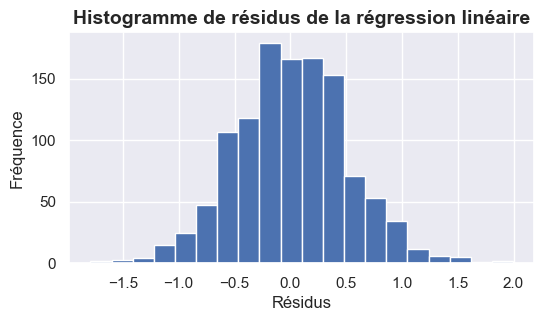

QQ plot


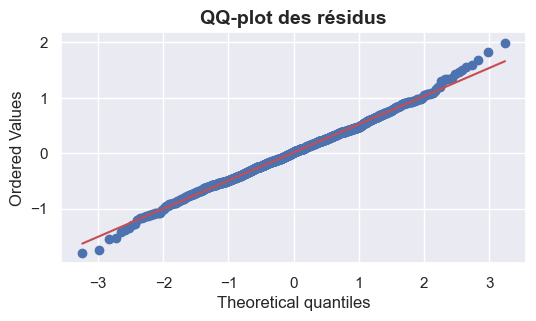

Test de Shapiro
p-value = 0.0314
Test de KS
p-value = 0.4634
Homocédasticité des résidus


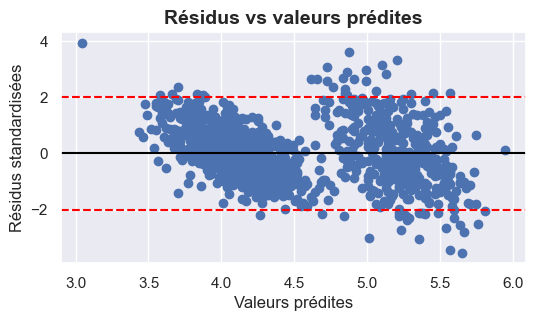

Test de breusch-pagan
{'LM Statistic': np.float64(96.77484775759754), 'LM-Test p-value': np.float64(9.674060875475752e-22), 'F-Statistic': np.float64(52.615356198625555), 'F-Test p-value': np.float64(1.323293421190412e-22)}
Colinéarité des variables
     Variable       VIF
0   margin_up  1.617607
1  is_genuine  1.617607


In [144]:
# Validation des hypothèses ?
y_pred_train_ml = reg_ml.predict(X_select)
res_train_ml = y_train_ml - y_pred_train_ml


# Distribution normale 
print("Espérance des résidus")
print(res_train_ml.describe())

print("Normalité des résidus")
plt.hist(res_train_ml, bins=20)
plt.xlabel("Résidus")
plt.ylabel("Fréquence")
plt.title("Histogramme de résidus de la régression linéaire", fontsize = 14, fontweight = 'bold')
plt.savefig("hist_res_lineaire.png")
plt.show()

## QQ-plot
print("QQ plot")
stats.probplot(res_train_ml, plot=plt, dist = "norm") # verifier si proche de loi normale
plt.title("QQ-plot des résidus", fontsize = 14, fontweight = 'bold')
plt.savefig("qq_plot.png")
plt.show()

## Test Shapiro
print("Test de Shapiro")
stat, p_value = stats.shapiro(res_train_ml)
print(f"p-value = {p_value:.4f}")
# rejette la normalité (p-value < 5%)

## Kolmogorov–Smirnov (avec standardisation)
print("Test de KS")
stat, p_value = stats.kstest(
    (res_train_ml - res_train_ml.mean()) / res_train_ml.std(ddof=1),
    'norm')
print(f"p-value = {p_value:.4f}")
# rejette également si p_value < 5% 
# On ne rejette pas la normalité


# Homocédasticité des résidus ?
print("Homocédasticité des résidus")

## Écart-type des résidus
sigma = np.std(res_train_ml, ddof=1)
# Résidus standardisés 
plt.scatter(y_pred_train_ml, res_train_ml/sigma)
plt.axhline(0, color = "black")
plt.axhline(-2, color = "red", linestyle='--')
plt.axhline(2, color = "red", linestyle='--')
plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus standardisées")
plt.title("Résidus vs valeurs prédites", fontsize = 14, fontweight = 'bold')
plt.savefig("ecart_type.png")
plt.show()
# certains résidus ne sont pas acceptables

## Homoscédasticité : breusch-pagan
print("Test de breusch-pagan")
bp_test = het_breuschpagan(reg_ml.resid, sm.add_constant(X_select))
labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
print(dict(zip(labels, bp_test)))


# Colinéarité  des variables ?
print("Colinéarité des variables")
vif = pd.DataFrame()
vif["Variable"] = X_select.columns
vif["VIF"] = [variance_inflation_factor(X_select.values, i)
              for i in range(X_select.shape[1])]

print(vif)
# La colinéarité des variables est améliorées moins importante que le modèle précédent

Les hypothèses sont bien vérifiées avec un score élevé de *$R^2 > 98.6 \%$* 

### 4. Sur-apprentissage du modèle ?

In [145]:
#X_test_const = sm.add_constant()
y_pred_test_ml = reg_ml.predict(X_test_ml[['margin_up', 'is_genuine']])
y_pred_train_ml = reg_ml.predict(X_select)


# RMSE Train/Test
print("")
print(f"RMSE sur Train: {round(mean_squared_error(y_train_ml, y_pred_train_ml),2)}")
print(f"RMSE sur Test: {round(mean_squared_error(y_test_ml, y_pred_test_ml),2)}")

# MAPE Train/Test
print(f"MAPE sur Train: {round(mean_absolute_percentage_error(y_train_ml, y_pred_train_ml)*100, 2)}%")
print(f"MAPE sur Test: {round(mean_absolute_percentage_error(y_test_ml, y_pred_test_ml)*100, 2)}%")
print("")


RMSE sur Train: 0.26
RMSE sur Test: 0.22
MAPE sur Train: 8.89%
MAPE sur Test: 8.16%



Il n'existe pas de problème d'overfitting, les erreurs sur train et test sont assez proches. Les erreurs d'échantillon test est plus faible que celle de train. 

<div style="background-color: RGB(51,130,182);" >
<h3 style="margin: auto; padding: 20px; color:#fff; ">Prédiction de "Margin_low" </h3>
</div>

In [146]:
# Train, faux billet
pdY_train = pd.DataFrame({"Y": y_train_ml, "is_genuine": X_train_ml["is_genuine"]}).reset_index(drop=True)
pdY_train["Type"] = "train"

# Test
pdY_test = pd.DataFrame({"Y": y_pred_test_ml, "is_genuine": X_test_ml["is_genuine"]}).reset_index(drop=True)
pdY_test["Type"] = "test"

# Concaténation des données Train/Test
pdY = pd.concat([pdY_train, pdY_test], ignore_index=True)


### 1. Distribution des billets

C:\Users\cairo\AppData\Local\Temp\ipykernel_13732\1879136727.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


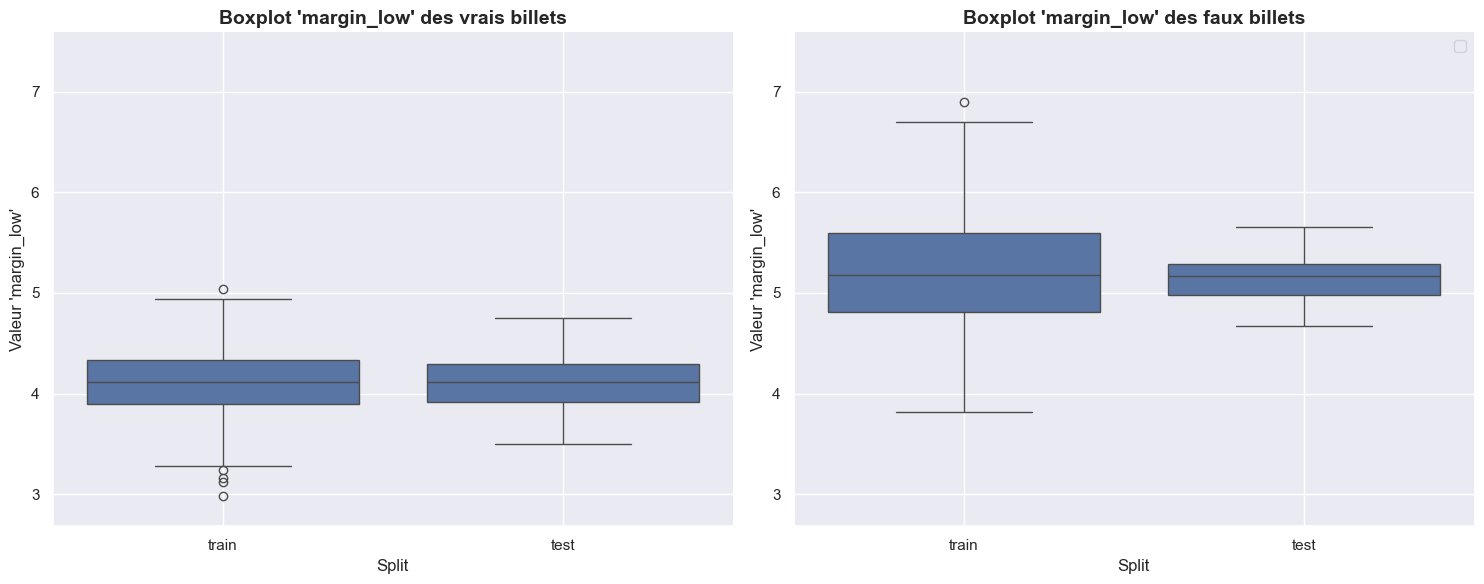

In [147]:
# Boxplot affichant la différence de dispersion des données selon la catégorie V/F des billets
fig = plt.figure(figsize=(15,6))
ax = fig.add_subplot(1, 2, 1)
sns.boxplot(x="Type", y="Y", data=pdY.loc[pdY["is_genuine"]==0])

ax.grid(True, which = 'both')
ax.set_title('Boxplot \'margin_low\' des vrais billets', fontweight = 'bold', fontsize = 14)
ax.set_xlabel('Split')
ax.set_ylabel('Valeur \'margin_low\'')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0.9 * np.min(pdY["Y"]), 1.1 * np.max(pdY["Y"]))


ax = fig.add_subplot(1, 2, 2)
sns.boxplot(x="Type", y="Y", data=pdY.loc[pdY["is_genuine"]==1])

ax.grid(True, which = 'both')
ax.set_title('Boxplot \'margin_low\' des faux billets', fontweight = 'bold', fontsize = 14)
ax.set_xlabel('Split')
ax.set_ylabel('Valeur \'margin_low\'')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0.9 * np.min(pdY["Y"]), 1.1 * np.max(pdY["Y"]))

ax.legend()
plt.tight_layout()

plt.savefig("Boxplt_marginlow.png")
plt.show()

En distinguant la dispersion des faux billets des vrais billets, on observe bien que la prédiction 'test' possède bien la même dispersion des valeurs 'margin_low'. 
Les valeurs de 'margin_low' de faux billets sont généralement plus grandes que les vrais billets, proche de 5(cm) alors que les vrais sont plus petits autour de 4(cm).

Elle est bien proche des données 'train', notre prédiction des données manquantes à l'aide du modèle de régression linéaire est bien cohérente.

### 2. Données complètes

In [148]:
# Extraire les données disponibles non vide
billet_final = billet.copy()
X_marginlow = billet_final.loc[billet_final["margin_low"].isna(), ["margin_up", "is_genuine"]]
billet_final.loc[billet["margin_low"].isna(), "margin_low"] = reg_ml.predict(X_marginlow)

billet_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_genuine    1500 non-null   int64  
 1   diagonal      1500 non-null   float64
 2   height_left   1500 non-null   float64
 3   height_right  1500 non-null   float64
 4   margin_low    1500 non-null   float64
 5   margin_up     1500 non-null   float64
 6   length        1500 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 82.2 KB


### 3. Validation de la répartition des billets

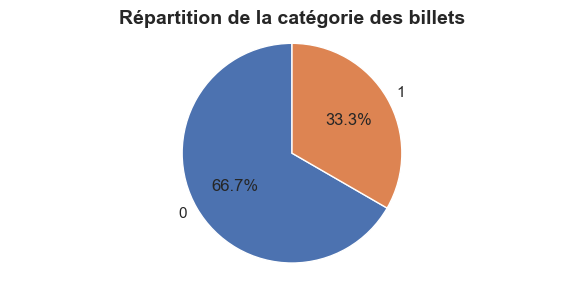

In [149]:
# Répartition des catégories des billets
counts = billet_final["is_genuine"].value_counts()

# Camembert
plt.figure()
plt.pie(counts.values, labels=counts.index, autopct='%1.1f%%', startangle=90)
sns.set_palette("coolwarm")  #muted, bright, deep, pastel, "coolwarm"
plt.title("Répartition de la catégorie des billets", fontsize = "14", fontweight = 'bold')
plt.axis('equal')  # pour un cercle parfait
plt.tight_layout()
plt.savefig("camembert_billet_final.png")
plt.show()

C:\Users\cairo\AppData\Local\Temp\ipykernel_13732\744764886.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


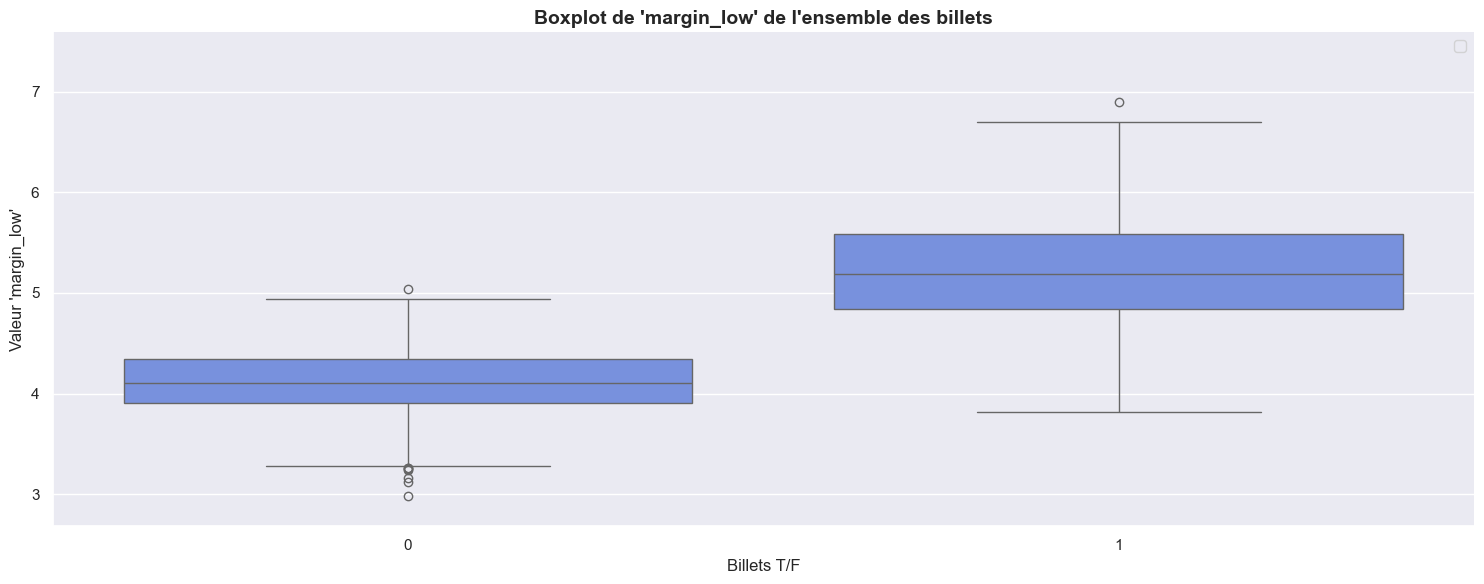

In [150]:
# Graphique
fig = plt.figure(figsize=(15,6))
ax = fig.add_subplot(1, 1, 1)
sns.boxplot(x="is_genuine", y="margin_low", data=billet_final)


ax.set_title('Boxplot de \'margin_low\' de l\'ensemble des billets', fontsize = 14, fontweight = 'bold')
ax.set_xlabel('Billets T/F')
ax.set_ylabel('Valeur \'margin_low\'')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0.9 * np.min(billet_final["margin_low"]), 1.1 * np.max(billet_final["margin_low"]))


ax.legend()
plt.tight_layout()
plt.savefig("boxplot_ml_pred.png")
plt.show()

La prédiction correspond bien à notre observation précédente.

### 4. Exportation des données nettoyées

In [151]:
# Exporter en csv avec données completes 
billet_final.to_csv("billet_final.csv", index = False)

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Choix de modèles de prédiction </h2>
</div>

In [152]:
billet = pd.read_csv("billet_final.csv", sep = ",")
billet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_genuine    1500 non-null   int64  
 1   diagonal      1500 non-null   float64
 2   height_left   1500 non-null   float64
 3   height_right  1500 non-null   float64
 4   margin_low    1500 non-null   float64
 5   margin_up     1500 non-null   float64
 6   length        1500 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 82.2 KB


In [153]:
# Extraire les données disponibles
X_tf = billet[["diagonal", "height_left", "height_right", "margin_up", "length", "margin_low"]]
y_tf = billet["is_genuine"] # en 0 et 1


### 1. Séparation des données en 80% train/20% test

In [154]:
# Diviser en 2 jeux de données train et test (80%/20%)
X_train_tf, X_test_tf, y_train_tf, y_test_tf = train_test_split(X_tf, y_tf, test_size=0.20, random_state=42)


# X centrée & réduite
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_tf)

X_train_scaled = scaler.fit_transform(X_train_tf)
X_test_scaled = scaler.fit_transform(X_test_tf)

# En dataframe
pdX_train_scaled = pd.DataFrame(X_train_scaled)
pdX_train_scaled.columns = X_train_tf.columns

pdX_test_scaled = pd.DataFrame(X_test_scaled)
pdX_test_scaled.columns = X_test_tf.columns

### 2. Critère choisit pour optimiser le modèle

Le critère **'recall'** minimise le risque de fraude. Ce qui veut dire **minimiser le FN (False negative)**, i.e minimiser les faux prédictions en disant que c'est négative alors que c'est en réalité positive.

En effet, ici, les vrais billets sont présentés par 0 (negative) et les faux billets par 1 (positive).
La matrice de confusion est représentée par : 
[[TN, FP
FN, TP]]

<div style="background-color: RGB(51,100,182);" >
<h2 style="margin: auto; padding: 16px; color:#fff; ">I - Modèles supervisés </h2>
</div>

<div style="background-color: RGB(51,130,182);" >
<h3 style="margin: auto; padding: 20px; color:#fff; ">Régression logistique </h3>
</div>

La régression logistique est une régression linéaire qui prédit des résultats discrets, binaires ou catégoriels. La valeur de **'C' régularise le niveau de sur-apprentissage**, plus la valeur est élevée plus le modèle est complexe. 
On peut faire varier cette valeur pour trouver le modèle le plus performant.


### 1. Optimisation des paramètres

In [155]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
all_res = []
for c in C_values:
    sfs_logit = SequentialFeatureSelector(
        LogisticRegression(
            C=c,  # gère la régularisation overfitting ou non
            class_weight='balanced', 
            solver='lbfgs', 
            max_iter=1000, 
            random_state=42
        ),
        k_features='best',
        forward=True,
        scoring='recall',
        cv=cv
    )

    sfs_logit.fit(pdX_train_scaled, y_train_tf)

    res_logit = pd.DataFrame(sfs_logit.get_metric_dict()).T
    res_logit["C"] = c

    all_res.append(res_logit)

pd_results = pd.concat(all_res)


### 2. Résultats de validation croisée et de sélection des variables explicatives

In [156]:
pd_results["n_features"] = pd_results.index
pd_results_sort = pd_results.sort_values(by = ["std_dev", "avg_score", "C"], ascending = [True, False, True]).reset_index()

pd_results_sort.head()
# Modèle par principe par la robustesse des données et de non sur-apprentissage

,index,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err,C,n_features
0,1,"(4,)","[0.9538461538461539, 0.9461538461538461, 0.946...",0.948718,"(length,)",0.00816,0.003626,0.002564,10.0,1
1,1,"(4,)","[0.9538461538461539, 0.9461538461538461, 0.946...",0.948718,"(length,)",0.00816,0.003626,0.002564,100.0,1
2,1,"(4,)","[0.9538461538461539, 0.9384615384615385, 0.946...",0.946154,"(length,)",0.014134,0.006281,0.004441,1.0,1
3,3,"(3, 4, 5)","[0.9692307692307692, 0.9769230769230769, 0.992...",0.979487,"(margin_up, length, margin_low)",0.02159,0.009594,0.006784,0.1,3
4,4,"(2, 3, 4, 5)","[0.9769230769230769, 0.9769230769230769, 1.0]",0.984615,"(height_right, margin_up, length, margin_low)",0.02448,0.010879,0.007692,1.0,4


### 3. Top modèle avec sélection des variables

In [157]:
# Choix du modèle le plus stable et plus performant
best_row = pd_results_sort.iloc[0]
best_c = best_row["C"]
print(best_c)

best_features_logit = list(best_row["feature_names"])
print(best_features_logit)

reg_logit = LogisticRegression(C=best_c, 
                               class_weight='balanced', 
                               solver='lbfgs', 
                               max_iter=1000, 
                               random_state = 42)

reg_logit.fit(pdX_train_scaled[best_features_logit], y_train_tf)
y_pred_logit = reg_logit.predict(pdX_test_scaled[best_features_logit])

10.0
['length']


scores : 95.0%


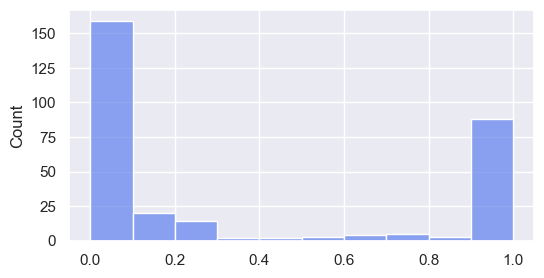

In [158]:
y_pred_proba_logit = reg_logit.predict_proba(pdX_test_scaled[best_features_logit])[::,1]
sns.histplot(y_pred_proba_logit)

# prediction
y_pred_logit = reg_logit.predict(pdX_test_scaled[best_features_logit])
print(f"scores : {accuracy_score(y_test_tf, y_pred_logit)*100}%")
# nombre de voisins à optimiser 


In [159]:
# Matrice de confusion [[TN, FP, FN, TP]]
cnf_matrix = metrics.confusion_matrix(y_test_tf, y_pred_logit)
print(cnf_matrix)

[[186   4]
 [ 11  99]]


### 4. Hyperparamètre du modèle

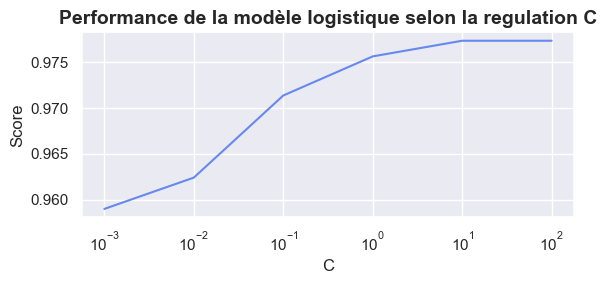

In [160]:
## Paramètre Optimal ?
pdC = pd_results.groupby(by = "C").agg({"avg_score": "mean", "std_dev" : "mean"}).reset_index()

plt.plot(pdC["C"], pdC["avg_score"])
plt.xscale("log")
plt.xlabel("C")
plt.ylabel("Score")
plt.title("Performance de la modèle logistique selon la regulation C", fontsize = 14, fontweight='bold')
plt.tight_layout()
    
plt.savefig("perf_reg_log_C.png")
plt.show()

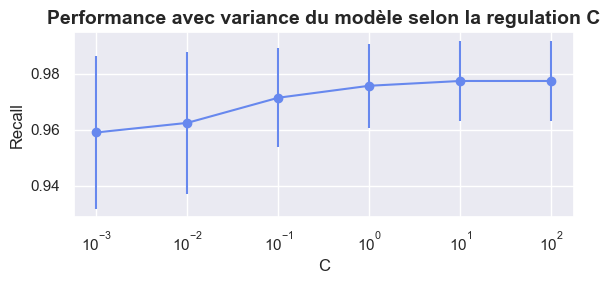

In [161]:
## Performance avec les erreurs standards
pdC_logit = (
    pd_results
    .groupby("C")["avg_score"]
    .agg(["mean", "std"])
    .reset_index()
)

plt.figure()
plt.errorbar(
    pdC_logit["C"],
    pdC_logit["mean"],
    yerr=pdC_logit["std"],
    marker='o'
)

plt.xscale("log")
plt.xlabel("C")
plt.ylabel("Recall")
plt.title("Performance avec variance du modèle selon la regulation C", fontsize = 14, fontweight='bold')
plt.tight_layout()
    
plt.savefig("perf_reglogit_Cvar.png")
plt.show()


D'après le graphique on peut identifier la valeur de 'C' du modèle possèdant une valeur moyenne de 'Recall' plus élevée quelque soit le nombre de variable.

### 5. Top modèle avec toutes les variables

In [162]:
# Choisir l'hyperparamètre C = 10
reg_logit = LogisticRegression(C= 10, 
                               class_weight='balanced', 
                               solver='lbfgs', 
                               max_iter=1000, 
                               random_state = 42)
reg_logit.fit(pdX_train_scaled, y_train_tf)
y_pred_logit = reg_logit.predict(pdX_test_scaled)


cnf_matrix = metrics.confusion_matrix(y_test_tf, y_pred_logit)
print(cnf_matrix)
# On obtient une meilleure prediction

[[189   1]
 [  2 108]]


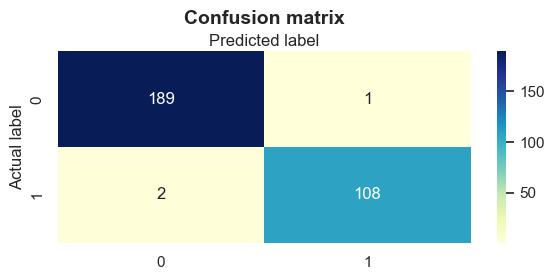

In [163]:
# Visualiser la matrice de confusion
class_names=[0,1] 
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

# heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu", fmt='g') #
ax.xaxis.set_label_position("top")
plt.title('Confusion matrix', y=1.1, fontsize = 14, fontweight = 'bold')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.tight_layout()

plt.savefig("matrice_reg_logit.png")
plt.show()

<div style="background-color: RGB(51,100,182);" >
<h3 style="margin: auto; padding: 16px; color:#fff; ">KNN </h3>
</div>

Le modèle des k plus proches voisins (KNN) est un classificateur d'apprentissage non paramétrique et supervisé qui s'appuie sur la notion de proximité pour réaliser des classifications ou des prédictions sur le regroupement d'un point de données.

La distance mesurée peut être de 'Euclidienne', 'Manhattan', 'Minkowski', etc. Mais, ici, nous allons prendre plutôt la première. Et, on peut faire varier **le nombre des voisins 'k'**. 


### 1. Optimisation des paramètres

In [164]:
Kneighbors = range(1, 10, 1)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42) # n_splits pour petit dataset
all_res = []

for k in Kneighbors:
    sfs_Kneighbors = SequentialFeatureSelector(
        KNeighborsClassifier(
            n_neighbors = k, 
            metric = 'minkowski', 
            p = 2
        ),
        k_features = 'best',
        forward = True,
        scoring = 'recall',
        cv=cv
    )

    sfs_Kneighbors.fit(pdX_train_scaled, y_train_tf)

    res_knn = pd.DataFrame(sfs_Kneighbors.get_metric_dict()).T
    res_knn["K_neighbors"] = k

    all_res.append(res_knn)

pd_results_knn = pd.concat(all_res)

### 2. Résultats de validation croisée et de sélection des variables explicatives

In [165]:
pd_results_knn["n_features"] = pd_results_knn.index
pd_results_knn_sort = pd_results_knn.sort_values(by = ["std_dev", "avg_score"], ascending = [True, False]).reset_index()

pd_results_knn_sort.head()

,index,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err,K_neighbors,n_features
0,1,"(4,)","[0.9307692307692308, 0.9230769230769231, 0.915...",0.923077,"(length,)",0.014134,0.006281,0.004441,3,1
1,1,"(4,)","[0.8923076923076924, 0.8846153846153846, 0.876...",0.884615,"(length,)",0.014134,0.006281,0.004441,2,1
2,3,"(1, 4, 5)","[0.9692307692307692, 0.9615384615384616, 0.984...",0.971795,"(height_left, length, margin_low)",0.02159,0.009594,0.006784,1,3
3,1,"(4,)","[0.9153846153846154, 0.8923076923076924, 0.915...",0.907692,"(length,)",0.02448,0.010879,0.007692,1,1
4,5,"(0, 2, 3, 4, 5)","[0.9615384615384616, 0.9769230769230769, 0.992...",0.976923,"(diagonal, height_right, margin_up, length, ma...",0.028267,0.012561,0.008882,5,5


### 3. Top modèle avec sélection des variables

In [166]:
best_row = pd_results_knn_sort.iloc[0]
best_k = best_row["K_neighbors"]
print("K: ", best_k)

best_features_knn = list(best_row["feature_names"])
print("Nombre de colonnes: ", best_features_knn)

clf_knn = KNeighborsClassifier(
            n_neighbors = k, 
            metric = 'minkowski', 
            p = 2)

clf_knn.fit(pdX_train_scaled[best_features_knn], y_train_tf)

K:  3
Nombre de colonnes:  ['length']


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",9
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


scores : 95.33333333333334%


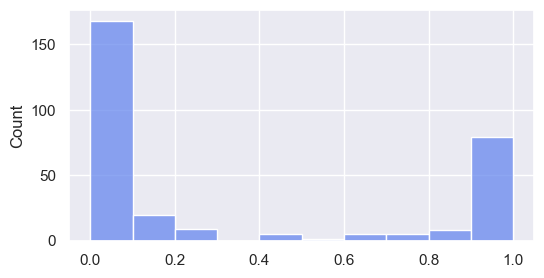

In [167]:
y_pred_proba_knn = clf_knn.predict_proba(pdX_test_scaled[best_features_knn])[::,1]
sns.histplot(y_pred_proba_knn)

# prediction
y_pred_knn = clf_knn.predict(pdX_test_scaled[best_features_knn])
print(f"scores : {accuracy_score(y_test_tf, y_pred_knn)*100}%")
# nombre de voisins à optimiser 

In [168]:
# matrice de confusion
cnf_matrix = metrics.confusion_matrix(y_test_tf, y_pred_knn)
print(cnf_matrix)

[[189   1]
 [ 13  97]]


### 4. Hyperparamètre du modèle

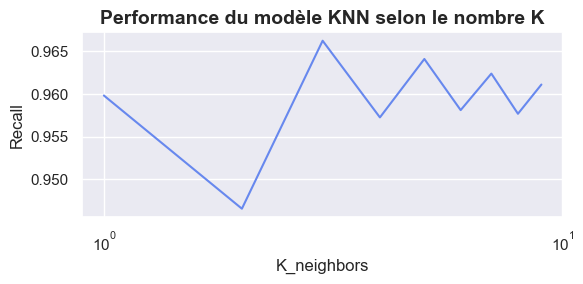

In [169]:
pdK = pd_results_knn.groupby(by = "K_neighbors").agg({"avg_score": "mean", "std_dev" : "mean"}).reset_index()

plt.plot(pdK["K_neighbors"], pdK["avg_score"])
plt.xscale("log")
plt.xlabel("K_neighbors")
plt.ylabel("Recall")
plt.title("Performance du modèle KNN selon le nombre K", fontsize = 14, fontweight='bold')
plt.tight_layout()
    
plt.savefig("perf_reg_knn_K.png")
plt.show()

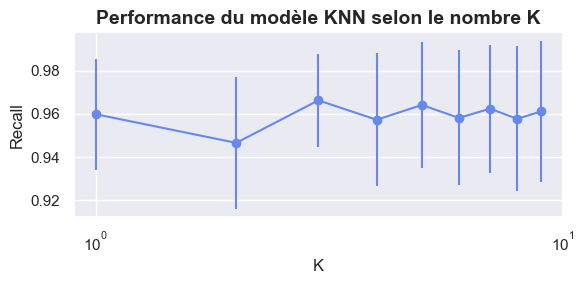

In [170]:
pdk_knn = (
    pd_results_knn
    .groupby("K_neighbors")["avg_score"]
    .agg(["mean", "std"])
    .reset_index()
)

plt.figure()

plt.errorbar(
    pdk_knn["K_neighbors"],
    pdk_knn["mean"],
    yerr=pdk_knn["std"],
    marker='o'
)

plt.xscale("log")
plt.xlabel("K")
plt.ylabel("Recall")
plt.title("Performance du modèle KNN selon le nombre K", fontsize = 14, fontweight='bold')
plt.tight_layout()
    
plt.savefig("perf_reg_knn_Kvar.png")
plt.show()

### 5. Top modèle avec toutes les variables

In [171]:
clf_knn = KNeighborsClassifier(
            n_neighbors = 3, 
            metric = 'minkowski', 
            p = 2)
clf_knn.fit(pdX_train_scaled, y_train_tf)
y_pred_knn = clf_knn.predict(pdX_test_scaled)

cnf_matrix = metrics.confusion_matrix(y_test_tf, y_pred_knn)
print(cnf_matrix)

# meilleure performance

[[190   0]
 [  6 104]]


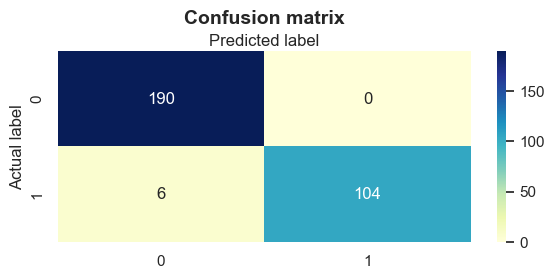

In [172]:
# Visualiser la matrice de confusion
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

# heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu", fmt='g') #
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1, fontsize = 14, fontweight = 'bold')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.tight_layout()

plt.savefig("matrice_knn.png")
plt.show()

<div style="background-color: RGB(51,100,182);" >
<h2 style="margin: auto; padding: 16px; color:#fff; ">Random Forest </h2>
</div>

La méthode de classification Random Forest est une méthode qui combine les résultats de plusieurs arbres de decision pour obtenir un résultat unique. 

Chaque arbre est constuit par les variables aléatoirement et possèdent différents profondeurs **'depth'**. Et les forêts sont composés de différents nombre d'arbre **'n_trees'**.

A travers le contrôle du nombre d'arbres et de la profondeur, on peut trouver le forêt le plus performant.

### 1. Optimisation du Random Forest : Elagage 

In [173]:
tree_counts = [1, 2, 3, 4, 5, 10, 15, 20, 50, 100, 150]
depths = range(2, 10, 1)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
all_res = []
for n_estimator in tree_counts:
    for depth in depths :
        sfs_rf = SequentialFeatureSelector(
            RandomForestClassifier(
                n_estimators=n_estimator,
                max_depth=depth,
                max_features="sqrt",
                class_weight="balanced",  # ⭐ important si déséquilibré
                random_state=42),
            k_features = 'best',
            forward = True,
            scoring = 'recall',
            cv=cv
        )

        sfs_rf.fit(pdX_train_scaled, y_train_tf)

        res_rf = pd.DataFrame(sfs_rf.get_metric_dict()).T
        res_rf["n_trees"] = n_estimator
        res_rf["depth"] = depth

        all_res.append(res_rf)

pd_results_rf = pd.concat(all_res)


### 2. Résultats de validation croisée et de sélection des variables explicatives

In [174]:
pd_results_rf["n_features"] = pd_results_rf.index
pd_results_rf_sort = pd_results_rf.sort_values(by = ["std_dev", "avg_score"], ascending = [True, False]).reset_index()
    
pd_results_rf_sort.head()

,index,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err,n_trees,depth,n_features
0,5,"(0, 1, 3, 4, 5)","[0.9846153846153847, 0.9846153846153847, 0.984...",0.984615,"(diagonal, height_left, margin_up, length, mar...",0.0,0.0,0.0,3,4,5
1,6,"(0, 1, 2, 3, 4, 5)","[0.9769230769230769, 0.9769230769230769, 0.976...",0.976923,"(diagonal, height_left, height_right, margin_u...",0.0,0.0,0.0,10,2,6
2,4,"(1, 3, 4, 5)","[0.9769230769230769, 0.9769230769230769, 0.976...",0.976923,"(height_left, margin_up, length, margin_low)",0.0,0.0,0.0,15,2,4
3,3,"(2, 4, 5)","[0.9769230769230769, 0.9769230769230769, 0.976...",0.976923,"(height_right, length, margin_low)",0.0,0.0,0.0,15,3,3
4,3,"(2, 4, 5)","[0.9769230769230769, 0.9769230769230769, 0.976...",0.976923,"(height_right, length, margin_low)",0.0,0.0,0.0,20,3,3


### 3. Top modèle avec sélection des variables

In [175]:
best_row = pd_results_rf_sort.iloc[0]
best_trees = best_row["n_trees"]
print("Nombre d'arbres: ", best_trees)

best_depth = best_row["depth"]
print("Profondeur: ", best_depth)

best_features_rf = list(best_row["feature_names"])
print("Colonnes: ", best_features_rf)

clf_rf = RandomForestClassifier(
                n_estimators=best_trees,
                max_depth=best_depth,
                max_features="sqrt",
                class_weight="balanced",  # ⭐ important si déséquilibré
                random_state=42)

clf_rf.fit(pdX_train_scaled[best_features_rf], y_train_tf)

Nombre d'arbres:  3
Profondeur:  4
Colonnes:  ['diagonal', 'height_left', 'margin_up', 'length', 'margin_low']


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",np.int64(3)
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",np.int64(4)
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with si

scores : 98.66666666666667%


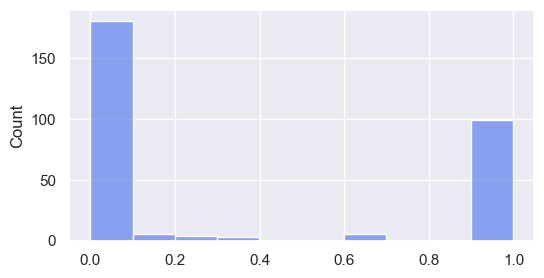

In [176]:
y_pred_proba_rf = clf_rf.predict_proba(pdX_test_scaled[best_features_rf])[:,1]
sns.histplot(y_pred_proba_rf)

# prediction
y_pred_rf = clf_rf.predict(pdX_test_scaled[best_features_rf])
print(f"scores : {accuracy_score(y_test_tf, y_pred_rf)*100}%")
# nombre de voisins à optimiser 

In [177]:
# Matrice
cnf_matrix = metrics.confusion_matrix(y_test_tf, y_pred_rf)
print(cnf_matrix)

[[190   0]
 [  4 106]]


### 4. Hyperparamètres du modèle

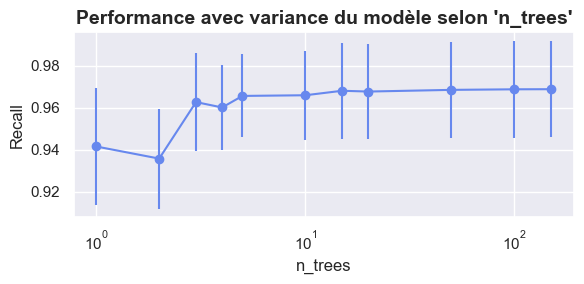

In [178]:
pdt_rf = (
    pd_results_rf
    .groupby("n_trees")["avg_score"]
    .agg(["mean", "std"])
    .reset_index()
)

plt.figure()

plt.errorbar(
    pdt_rf["n_trees"],
    pdt_rf["mean"],
    yerr=pdt_rf["std"],
    marker='o'
)

plt.xscale("log")
plt.title("Performance avec variance du modèle selon 'n_trees'", fontsize = 14, fontweight='bold')
plt.xlabel("n_trees")
plt.ylabel("Recall")
plt.tight_layout()
    
plt.savefig("perf_reg_rf_trees.png")
plt.show()

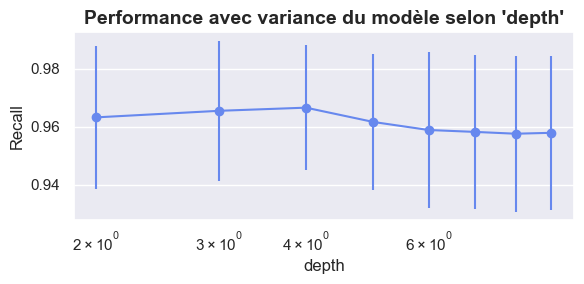

In [179]:
pdd_rf = (
    pd_results_rf
    .groupby("depth")["avg_score"]
    .agg(["mean", "std"])
    .reset_index()
)

plt.figure()

plt.errorbar(
    pdd_rf["depth"],
    pdd_rf["mean"],
    yerr=pdd_rf["std"],
    marker='o'
)

plt.xscale("log")
plt.title("Performance avec variance du modèle selon 'depth'", fontsize = 14, fontweight='bold')
plt.xlabel("depth")
plt.ylabel("Recall")
plt.tight_layout()
    
plt.savefig("perf_reg_rf_depth.png")
plt.show()

### 5. Top modèle avec toutes les variables

In [180]:
# 2eme
clf_rf = RandomForestClassifier(
                n_estimators = 9,
                max_depth = 4,
                max_features="sqrt",
                class_weight="balanced", 
                random_state = 42)
clf_rf.fit(pdX_train_scaled, y_train_tf)
y_pred_rf = clf_rf.predict(pdX_test_scaled)

In [181]:
cnf_matrix = metrics.confusion_matrix(y_test_tf, y_pred_rf)
print(cnf_matrix)

[[190   0]
 [  4 106]]


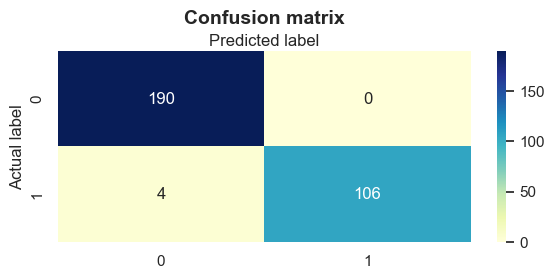

In [182]:
# Visualiser la matrice de confusion
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

# heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu", fmt='g') #
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1, fontsize = 14, fontweight = 'bold')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.tight_layout()

plt.savefig("matrice_rf.png")
plt.show()

<div style="background-color: RGB(51,100,182);" >
<h2 style="margin: auto; padding: 16px; color:#fff; "> II - Méthodes non supervisées</h2>
</div>

<div style="background-color: RGB(51,130,182);" >
<h3 style="margin: auto; padding: 20px; color:#fff; ">Kmeans </h3>
</div>

La méthode non-supervisée n'a pas besoin de la validation croisée dynamique comme il ne connait pas le label de la variable cible 'is_genuine' en avance.

### Les fonctions

In [183]:
def acp_inertie(data, cols, n_components):
    """Afficher le premier pourcentage d'inertie des composantes d'ACP
    
    """
    complet_num = data[cols] 

    A = complet_num.values
    #print(type(A))

    ## Les 2 à la fois (standardiser et normaliser les valeurs)
    A_scaled = StandardScaler().fit_transform(A)

    ## Voir la transformation (moyenne = 0 et ecart-type = 1)
    idx = ["mean", "std"]
    pd.DataFrame(A_scaled).describe().round(2).loc[idx, :]

    
    pca = PCA(n_components=n_components)

    ## Modele entrainement
    pca.fit(A_scaled)


    # variance captée par chaque nouvelle composante
    scree = (pca.explained_variance_ratio_*100).round(2)
    print(f"Variance captée par les composantes : {scree}")
    
    # cumulé 
    scree_cum = scree.cumsum().round()
    print(f"Variance cumulée captée par les composantes {scree_cum}")
    
    a_list = range(1, n_components+1)

    # Graphique cumulé
    plt.bar(a_list, scree)
    plt.plot(a_list, scree_cum,c="red",marker='o')
    plt.xlabel("rang de l'axe d'inertie")
    plt.ylabel("pourcentage d'inertie")
    plt.title("Eboulis des valeurs propres")

    plt.savefig("ptg_inertie.png")
    plt.show(block=False)

    return(scree_cum[0])
    

def acp(data, cols):
    """ Montre la variance captée par la permière composante
    """
    complet_num = data[cols] 

    A = complet_num.values
    #print(type(A))

    # Garder les noms de pays et de colonnes 
    names = complet_num.index  # Zone en index
    
    features = complet_num.columns

     ## Les 2 à la fois
    A_scaled = StandardScaler().fit_transform(A)

    ## Voir la transformation (moyenne = 0 et ecart-type = 1)
    idx = ["mean", "std"]
    pd.DataFrame(A_scaled).describe().round(2).loc[idx, :]

    n_components = len(cols)
    pca = PCA(n_components=n_components)

    ## Modele entrainement
    pca.fit(A_scaled)


    # variance captée par chaque nouvelle composante
    scree = (pca.explained_variance_ratio_*100).round(2)

    # cumulé 
    scree_cum = scree.cumsum().round()
    scree_cum2 = float(scree_cum[0])

    a_list = range(1, n_components+1)

    return(scree_cum2)


def cols_maxInertie(cols, r, data):
    """
    Trouver la combinaison des colonnes dont l'inertie est max 
    parmi l'ensemble de combinaisons de colonnes de la data
    """
    
    all_combinations = [] 
    all_combinations.extend(combinations(cols, r))

    list_inertie = []
    for i in range(0, len(all_combinations)):
        ptg_iner = acp(data, list(all_combinations[i]))
        list_inertie.append(ptg_iner)

    max_i = list_inertie.index(max(list_inertie))

    print(f"Le maximum de pourcentage d'inertie {max(list_inertie)} est atteint au {max_i}ème pour :\n {list(all_combinations[max_i])}")

    return(list(all_combinations[max_i]))
    
    

# Fonction graphique de corrélation
def correlation_graph(pca, 
                      x_y, 
                      features) : 
    """Affiche le graphe des correlations

    Positional arguments : 
    -----------------------------------
    pca : sklearn.decomposition.PCA : notre objet PCA qui a été fit
    x_y : list ou tuple : le couple x,y des plans à afficher, exemple [0,1] pour F1, F2
    features : list ou tuple : la liste des features (ie des dimensions) à représenter
    """

    # Extrait x et y 
    x,y=x_y

    # Taille de l'image (en inches)
    fig, ax = plt.subplots(figsize=(6, 6))

    # Pour chaque composante : 
    for i in range(0, pca.components_.shape[1]):

        # Les flèches
        ax.arrow(0,0, 
                pca.components_[x, i],  
                pca.components_[y, i],  
                head_width=0.07,
                head_length=0.07, 
                width=0.02)

        # Les labels
        plt.text(pca.components_[x, i] + 0.02,
                pca.components_[y, i] + 0.05,
                features[i])
        
    # Affichage des lignes horizontales et verticales
    plt.plot([-1, 1], [0, 0], color='grey', ls='--')
    plt.plot([0, 0], [-1, 1], color='grey', ls='--')

    # Nom des axes, avec le pourcentage d'inertie expliqué
    plt.xlabel('F{} ({}%)'.format(x+1, round(100*pca.explained_variance_ratio_[x],1)))
    plt.ylabel('F{} ({}%)'.format(y+1, round(100*pca.explained_variance_ratio_[y],1)))

    # J'ai copié collé le code sans le lire
    plt.title("Cercle des corrélations (F{} et F{})".format(x+1, y+1))

    # Le cercle 
    an = np.linspace(0, 2 * np.pi, 100)
    plt.plot(np.cos(an), np.sin(an))  # Add a unit circle for scale

    # Axes et display
    plt.axis('equal')
    plt.savefig(f"cercle_correlation{x_y}.png")
    plt.show(block=False)
    
    
# Projection des points 
def display_factorial_planes(   X_projected, 
                                x_y, 
                                pca=None, 
                                labels = None,
                                clusters=None, 
                                alpha=1,
                                figsize=[10,8], 
                                marker="." ):

    """ Projeté les individus sur le plan factoriel désigné
    """
    # Transforme X_projected en np.array
    X_ = np.array(X_projected)

    # On définit la forme de la figure si elle n'a pas été donnée
    if not figsize: 
        figsize = (7,6)

    # On gère les labels
    if  labels is None : 
        labels = []
    try : 
        len(labels)
    except Exception as e : 
        raise e

    # On vérifie la variable axis 
    if not len(x_y) ==2 : 
        raise AttributeError("2 axes sont demandées")   
    if max(x_y)>= X_.shape[1] : 
        raise AttributeError("la variable axis n'est pas bonne")   

    # on définit x et y 
    x, y = x_y

    # Initialisation de la figure       
    fig, ax = plt.subplots(1, 1, figsize=figsize)

    # On vérifie s'il y a des clusters ou non
    c = None if clusters is None else clusters
 
    # Les points    
    #plt.scatter(   X_[:, x], X_[:, y], alpha=alpha, 
    #                     c=c, cmap="Set1", marker=marker)
    sns.scatterplot(data=None, x=X_[:, x], y=X_[:, y], hue=c, palette="viridis")

    # Si la variable pca a été fournie, on peut calculer le % de variance de chaque axe 
    if pca : 
        v1 = str(round(100*pca.explained_variance_ratio_[x]))  + " %"
        v2 = str(round(100*pca.explained_variance_ratio_[y]))  + " %"
    else : 
        v1=v2= ''

    # Nom des axes, avec le pourcentage d'inertie expliqué
    ax.set_xlabel(f'F{x+1} {v1}')
    ax.set_ylabel(f'F{y+1} {v2}')

    # Valeur x max et y max
    x_max = np.abs(X_[:, x]).max() *1.1
    y_max = np.abs(X_[:, y]).max() *1.1

    # On borne x et y 
    ax.set_xlim(left=-x_max, right=x_max)
    ax.set_ylim(bottom= -y_max, top=y_max)

    # Affichage des lignes horizontales et verticales
    plt.plot([-x_max, x_max], [0, 0], color='grey', alpha=0.8)
    plt.plot([0,0], [-y_max, y_max], color='grey', alpha=0.8)

    # Affichage des labels des points
    if len(labels) : 
        # j'ai copié collé la fonction sans la lire
        for i,(_x,_y) in enumerate(X_[:,[x,y]]):
            plt.text(_x, _y+0.05, labels[i], fontsize='10', ha='center',va='center') 

    # Titre et display
    plt.title(f"Projection des individus (sur F{x+1} et F{y+1})")
    
    plt.savefig("projection_individu.png")
    plt.show()



### Choix de nombre de composants

Variance captée par les composantes : [44.37 16.94 13.05 11.31  8.5   5.83]
Variance cumulée captée par les composantes [ 44.  61.  74.  86.  94. 100.]


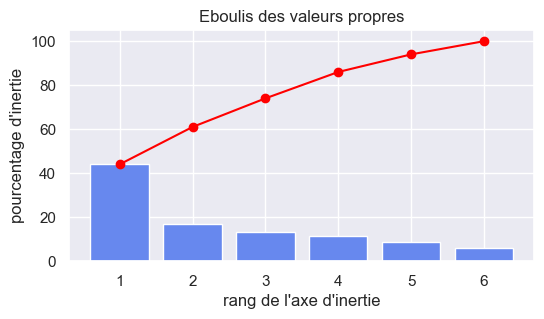

On prend en compte les colonnes dont pourcentage d'inertie > 16.67%


In [184]:
cols = pdX_test_scaled.columns
acp_inertie(pdX_test_scaled, cols, 6) 

print(f"On prend en compte les colonnes dont pourcentage d'inertie > {round(100/6, 2)}%")
# Donc les 2 premiers

In [185]:
# ACP
n_components = 2
pca = PCA(n_components=n_components)
X_test_pca = pca.fit_transform(pdX_test_scaled)

# variance captée par chaque nouvelle composante
scree = (pca.explained_variance_ratio_*100).round(2)
print(f"Variance captée par chaque nouvelle axe : \n{scree}")


Variance captée par chaque nouvelle axe : 
[44.37 16.94]


### Axes d'inertie

In [186]:
## Modele entrainement
pca.fit(pdX_test_scaled)
pcs = pca.components_
# pcs (plan composants)
a_list = range(1, n_components+1)

# les composantes
pcs = pd.DataFrame(pcs)
a_list = range(1, n_components+1)
# Composantes explicant les plans factoriels 
pcs.columns = pdX_test_scaled.columns              # ajouter nom de colonnes
pcs.index = [f"F{i}" for i in a_list] # ajouter un index


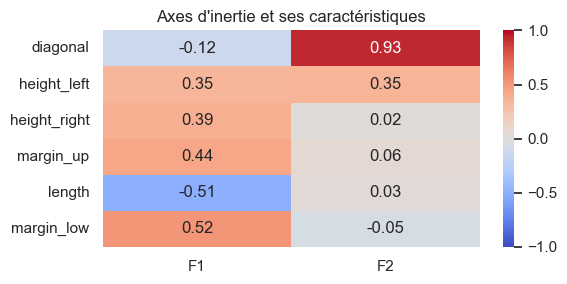

In [187]:
# représenter par visuel
fig, ax = plt.subplots(figsize=(6, 3))
sns.heatmap(pcs.T, vmin=-1, vmax=1, annot=True, cmap="coolwarm", fmt="0.2f")

plt.title("Axes d'inertie et ses caractéristiques")
plt.tight_layout()
plt.savefig("composant_inertie.png")
plt.show()

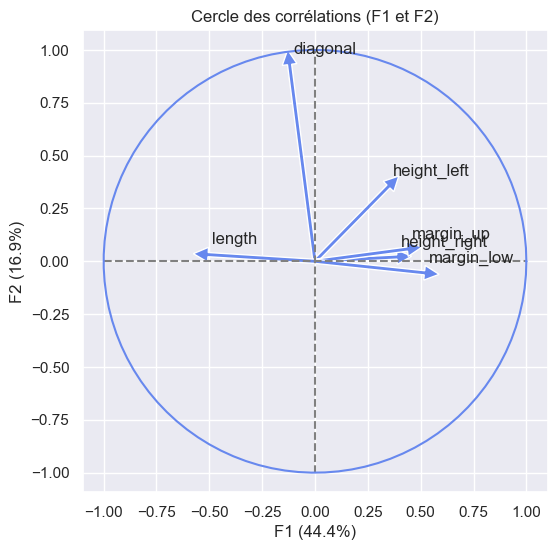

In [188]:
# 1er plan factoriel
x_y = (0,1)
# Application de la fonction
correlation_graph(pca, x_y, pdX_test_scaled.columns)

### 1. Optimisation des paramètres

In [189]:
# Utiliser les nouvelles variables
inertia_list = []
score_list = []
k_list = range(2, 10)  

for k in k_list:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_train_pca)
    
    # Ajouter l'inertie à la liste
    inertia_list.append(kmeans.inertia_)
    
    # Prédire les labels
    labels = kmeans.predict(X_test_pca)
    
    # Calculer et ajouter le score silhouette
    score_list.append(silhouette_score(X_test_pca, labels))
    

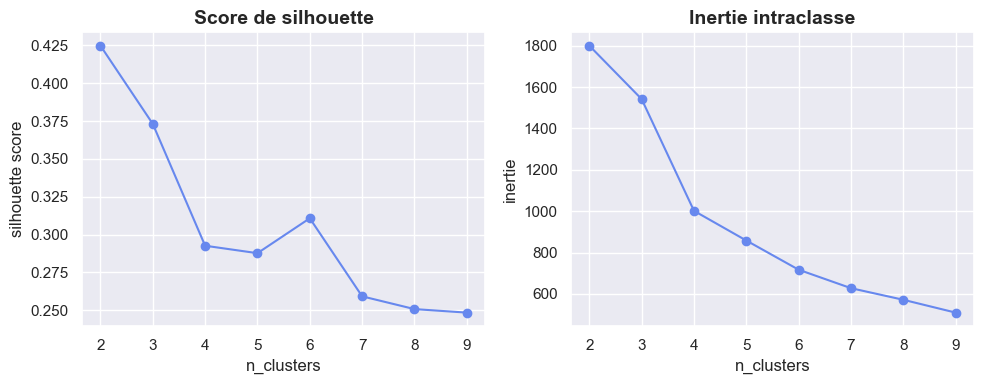

In [190]:
# Visualisation des indices de choix de clusters
fig, ax = plt.subplots(1,2,figsize=(10,4))

# Graphique silhouette
ax[0].plot(k_list, score_list, marker="o")
ax[0].set_xlabel("n_clusters")
ax[0].set_ylabel("silhouette score")
ax[0].set_title("Score de silhouette", fontsize = 14, fontweight = 'bold')

# Graphique inertie
ax[1].plot(k_list, inertia_list, marker="o")
ax[1].set_xlabel("n_clusters")
ax[1].set_ylabel("inertie")
ax[1].set_title("Inertie intraclasse", fontsize = 14, fontweight = 'bold')

plt.tight_layout()
plt.savefig("choix_nclusters_kmeans.png")
plt.show()


# Avec l'indice de silouette il est mieux de prendre k=2 pour le groupement

### Projection des individus selon Kmeans

[0 0 1 1 1 1 0 1 0 1 0 0 1 0 1 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 1
 0 0 1 0 1 0 1 0 1 0 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 1 1 1 1 0
 1 0 1 1 1 1 0 1 1 1 1 0 1 1 1 1 0 0 0 0 0 1 1 1 0 0 0 1 0 0 1 1 1 0 1 1 1
 0 1 1 1 1 1 1 1 0 1 0 0 1 0 0 0 1 0 1 0 1 0 0 1 1 1 1 1 1 0 0 0 0 0 0 1 0
 1 1 0 0 0 0 1 0 0 1 1 1 0 1 0 0 1 1 0 0 1 1 1 0 1 0 1 0 0 0 1 0 0 1 1 1 0
 1 1 1 0 0 1 1 0 0 1 1 1 1 0 0 1 0 1 1 0 0 1 1 1 0 1 0 1 0 1 1 0 1 0 1 0 1
 0 0 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 1 0 0 0 1 0 0 0 0 0 1 1 1 1
 0 0 0 0 1 0 0 1 0 0 1 1 0 1 0 1 0 0 0 1 0 0 0 0 1 1 1 1 0 1 0 0 0 1 0 1 1
 1 0 0 0]


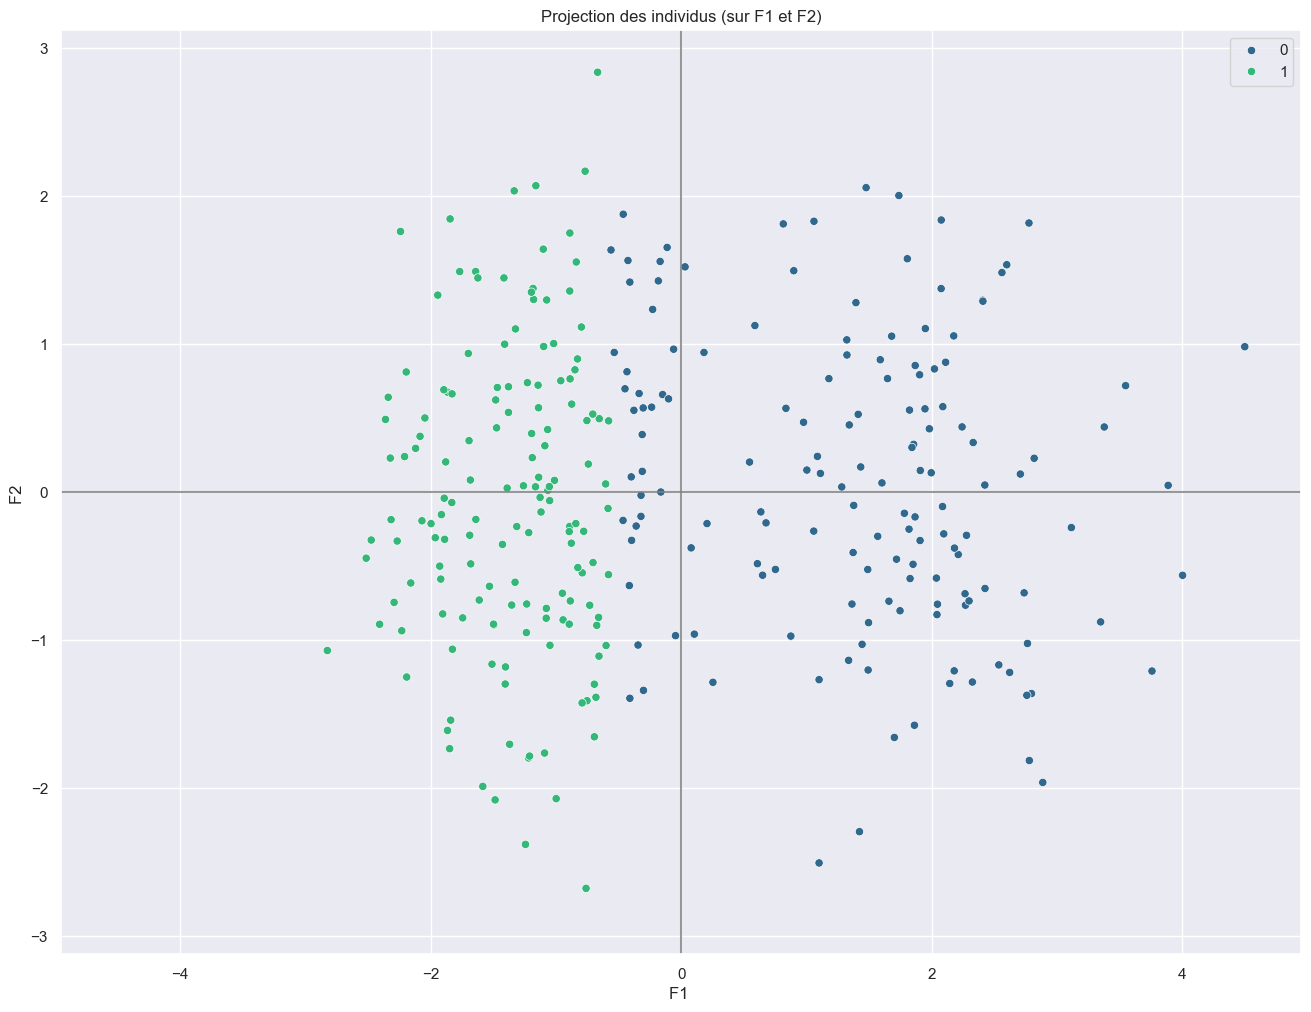

In [191]:
kmeans = KMeans(n_clusters=2, random_state = 40)
kmeans.fit(X_train_pca) 
clusters = kmeans.predict(X_test_pca)
print(clusters)
# Valeur 0 et 1 ne représente pas forcément les faux billets et les vrais
X_proj = pca.transform(pdX_test_scaled)
x_y = (0,1)
display_factorial_planes(X_proj, x_y, clusters = clusters,  figsize=(16,12), alpha = 0.5)


D'après l'indice de silhouette et la méthode de coude, une sélection de **k=2** groupe semble cohérente.

### 2. Optimisation et prédiction de Kmeans

In [208]:
# Matrice de confusion
X_test_pca = pca.fit_transform(pdX_test_scaled)
clf_kmeans = KMeans(n_clusters=2, random_state=42)
clf_kmeans.fit(X_test_pca)
y_pred_kmeans = clf_kmeans.predict(X_test_pca)


In [209]:
comp_y = pd.DataFrame({
    "y_test": y_test_tf,
    "y_pred": clusters #y_pred_kmeans
})
comp_y.loc[comp_y["y_pred"] == 0, "y_pred"] = 2
comp_y.loc[comp_y["y_pred"] == 1, "y_pred"] = 0
comp_y.loc[comp_y["y_pred"] == 2, "y_pred"] = 1

,y_test,y_pred
1116,1,1
1368,1,1
422,0,0
413,0,0
451,0,0
...,...,...
983,0,0
799,0,0
1265,1,1
1150,1,1


In [205]:
# Matrice de confusion
cnf_matrix = metrics.confusion_matrix(comp_y["y_test"], comp_y["y_pred"])
print(cnf_matrix)

[[150  40]
 [  0 110]]


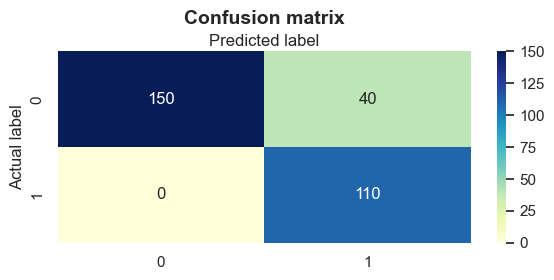

In [195]:
# Visualiser la matrice de confusion
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu", fmt='g') #
ax.xaxis.set_label_position("top")
plt.title('Confusion matrix', y=1.1, fontsize = 14, fontweight = 'bold')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.tight_layout()

plt.savefig("matrice_clf_kmeans.png")
plt.show()

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Choix des modèles Machine Learning </h2>
</div>

### 1. Comparaison entre les méthodes supervisées

In [ ]:
# Matrice de confusion de classification
# Comparer les modèles 
fpr, tpr, _ = metrics.roc_curve(y_test_tf,  y_pred_proba_logit)
fpr_knn, tpr_knn, _ = metrics.roc_curve(y_test_tf, y_pred_proba_knn)
fpr_rf, tpr_rf, _ = metrics.roc_curve(y_test_tf, y_pred_proba_rf)

auc_logit = metrics.roc_auc_score(y_test_tf, y_pred_proba_logit)
auc_knn = metrics.roc_auc_score(y_test_tf, y_pred_proba_knn)
auc_rf = metrics.roc_auc_score(y_test_tf, y_pred_proba_rf)

plt.plot(fpr,tpr,label="Logit, auc="+ str(round(auc_logit, 4)))
plt.plot(fpr_knn,tpr_knn,label="KNN, auc="+ str(round(auc_knn, 4)))
plt.plot(fpr_rf,tpr_rf,label="Random Forest, auc="+ str(round(auc_rf, 4)))
plt.legend(loc=4)
plt.title("Comparaison ROC_AUC des méthodes supervisées", fontsize = 14, fontweight = 'bold')
plt.xlabel("False Positive")
plt.ylabel("True Positive")

plt.tight_layout()
plt.savefig("comparaison_roc.png")
plt.show()


### 2. Comparaison des matrices de confusion

In [ ]:
models = {
    "Logistic": LogisticRegression(C= 10, 
                               class_weight='balanced', 
                               solver='lbfgs', 
                               max_iter=1000, 
                               random_state = 42),
    
    "KNN": KNeighborsClassifier(
            n_neighbors = 3, 
            metric = 'minkowski', 
            p = 1),
    
    "RandomForest": RandomForestClassifier(
                n_estimators = 7,
                max_depth = 4,
                max_features="sqrt",
                class_weight="balanced", 
                random_state = 42), 
    
    "Kmeans": KMeans(n_clusters=2, random_state=42)
}


In [ ]:
results = []

for name, model in models.items():
    if(name == "Kmeans"):
        
        pca = PCA(n_components=2)
        X_test_pca = pca.fit_transform(pdX_test_scaled)
        model.fit(X_test_pca)
    
        # Predict
        y_pred_kmeans = model.predict(X_test_pca)

        comp_y = pd.DataFrame({
            "y_test": y_test_tf,
            "y_pred": y_pred_kmeans
        })

        #comp_y.loc[comp_y["y_pred"] == 0, "y_pred"] = 2
        #comp_y.loc[comp_y["y_pred"] == 1, "y_pred"] = 0
        #comp_y.loc[comp_y["y_pred"] == 2, "y_pred"] = 1

        y_pred = comp_y["y_pred"]

    else:
        # Train
        model.fit(X_train_scaled, y_train_tf)
    
        # Predict
        y_pred = model.predict(X_test_scaled)

    
    # Scores
    report = classification_report(y_test_tf, y_pred, output_dict=True)
    
    results.append({
        "Model": name,
        "Recall": report["1"]["recall"],
        "Precision": report["1"]["precision"],
        "F1": report["1"]["f1-score"]
    })
        
    # Matrice de confusion
    print(f"\n{name}")
    cnf_matrix = metrics.confusion_matrix(y_test_tf, y_pred)
    print(cnf_matrix)

    
    # Visualiser la matrice de confusion
    class_names=[0,1] # name  of classes
    fig, ax = plt.subplots()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names)
    plt.yticks(tick_marks, class_names)

    # heatmap
    sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu", fmt='g') #
    ax.xaxis.set_label_position("top")
    plt.title('Confusion matrix', y=1.1, fontsize = 14, fontweight = 'bold')
    plt.ylabel('Actual label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    
    plt.show()

### 3. Comparaison de différents métriques

          Model    Recall  Precision        F1
3        Kmeans  0.990909   0.973214  0.981982
0      Logistic  0.981818   0.990826  0.986301
2  RandomForest  0.963636   0.990654  0.976959
1           KNN  0.954545   1.000000  0.976744


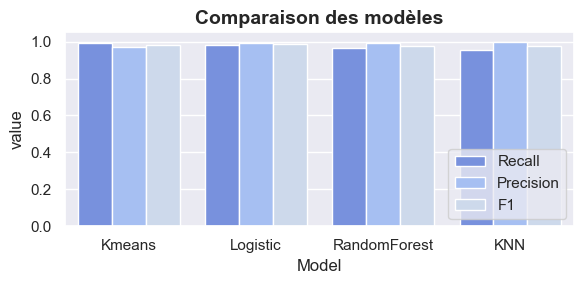

In [197]:
df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by="Recall", ascending=False)
print(df_results.sort_values(by="Recall", ascending=False))

df_melt = df_results.melt(id_vars="Model")

sns.barplot(data=df_melt, x="Model", y="value", hue="variable")

plt.title("Comparaison des modèles", fontsize = 14, fontweight = 'bold')
plt.legend(loc='lower right')

plt.tight_layout()
plt.savefig("comparaison_recall.png")
plt.show()

# Finalement, on va choisir le modèle de régression logistique

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Fin de notebook </h2>
</div>